# 05 — Modeling: Comparing Classifiers

Trains and compares several classifiers on `outputs/processed/combined_features.csv` (frequency-domain + statistical/temporal features, 1313 windows x 20 subjects), to predict which of the four phases (Relax, PhysicalStress, CognitiveStress, EmotionalStress) a window belongs to.

## Design decisions

| Decision | Choice | Why |
|---|---|---|
| Models compared | Logistic Regression, k-Nearest Neighbors, SVM (RBF), Random Forest, Gradient Boosting (`HistGradientBoostingClassifier`) | Spans simple/interpretable (linear, distance-based) to high-capacity (tree ensembles), matching what's standard in physiological stress-classification literature. |
| Evaluation protocol | 5-fold `StratifiedGroupKFold`, grouped by `subject_id` | A subject's windows must never appear in both train and test within a fold -- required given the overlapping 60s/30s windows (they share raw samples) and per-subject physiological baseline differences. Stratified so each fold keeps a similar class balance as far as the grouping constraint allows. |
| Primary metric | Macro-averaged F1 | Relax is ~54% of the data; plain accuracy would reward a model that just predicts Relax. Macro-F1 weighs all four classes equally. |
| Class imbalance handling | `class_weight='balanced'` (all models except k-NN, which has no such parameter) | Counteracts the same Relax-heavy imbalance at training time, not just at evaluation time. |
| Feature scaling | `StandardScaler` in every model's pipeline | Required for Logistic Regression/k-NN/SVM; harmless (a no-op on split quality) for the tree ensembles, so applying it uniformly keeps the code simple. |

Every window gets exactly one out-of-fold (OOF) prediction, made by a fold that never saw that window's subject during training. All reported metrics are computed on these OOF predictions -- equivalent to 5-fold cross-validation, reported as one clean evaluation per model rather than five separate ones.

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score, classification_report, f1_score
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

RANDOM_STATE = 42
CLASS_ORDER = ['Relax', 'PhysicalStress', 'CognitiveStress', 'EmotionalStress']

## Load features

In [2]:
features_df = pd.read_csv('../outputs/processed/combined_features.csv')

METADATA_COLUMNS = ['window_index', 'label', 'start_time', 'subject_id']
FEATURE_COLUMNS = [c for c in features_df.columns if c not in METADATA_COLUMNS]

X = features_df[FEATURE_COLUMNS]
y = features_df['label']
groups = features_df['subject_id']

print(f"Rows: {len(X)}, Features: {len(FEATURE_COLUMNS)}, Subjects: {groups.nunique()}")
print(f"NaN: {X.isna().sum().sum()}, Inf: {np.isinf(X.to_numpy()).sum()}")
print()
print(y.value_counts().reindex(CLASS_ORDER))

Rows: 1313, Features: 45, Subjects: 20
NaN: 0, Inf: 0

label
Relax              709
PhysicalStress     180
CognitiveStress    201
EmotionalStress    223
Name: count, dtype: int64


## Models

In [3]:
MODELS = {
    'Logistic Regression': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=RANDOM_STATE)),
    ]),
    'k-Nearest Neighbors': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', KNeighborsClassifier(n_neighbors=5)),
    ]),
    'SVM (RBF)': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', SVC(kernel='rbf', class_weight='balanced', random_state=RANDOM_STATE)),
    ]),
    'Random Forest': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', RandomForestClassifier(n_estimators=300, class_weight='balanced', random_state=RANDOM_STATE)),
    ]),
    'Gradient Boosting': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', HistGradientBoostingClassifier(class_weight='balanced', random_state=RANDOM_STATE)),
    ]),
}

## Cross-validate every model

In [4]:
cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

results = {}
for model_name, pipeline in MODELS.items():
    oof_predictions = pd.Series(index=X.index, dtype=object)
    fold_macro_f1 = []

    for train_idx, test_idx in cv.split(X, y, groups):
        pipeline.fit(X.iloc[train_idx], y.iloc[train_idx])
        fold_predictions = pipeline.predict(X.iloc[test_idx])
        oof_predictions.iloc[test_idx] = fold_predictions
        fold_macro_f1.append(f1_score(y.iloc[test_idx], fold_predictions, labels=CLASS_ORDER, average='macro'))

    results[model_name] = {
        'oof_predictions': oof_predictions,
        'fold_macro_f1_mean': float(np.mean(fold_macro_f1)),
        'fold_macro_f1_std': float(np.std(fold_macro_f1)),
        'oof_macro_f1': f1_score(y, oof_predictions, labels=CLASS_ORDER, average='macro'),
        'oof_accuracy': accuracy_score(y, oof_predictions),
    }
    r = results[model_name]
    print(f"{model_name:22s} fold macro-F1 = {r['fold_macro_f1_mean']:.3f} +/- {r['fold_macro_f1_std']:.3f}   "
          f"OOF macro-F1 = {r['oof_macro_f1']:.3f}   OOF accuracy = {r['oof_accuracy']:.3f}")

Logistic Regression    fold macro-F1 = 0.729 +/- 0.066   OOF macro-F1 = 0.731   OOF accuracy = 0.730


k-Nearest Neighbors    fold macro-F1 = 0.640 +/- 0.063   OOF macro-F1 = 0.642   OOF accuracy = 0.682


SVM (RBF)              fold macro-F1 = 0.724 +/- 0.077   OOF macro-F1 = 0.727   OOF accuracy = 0.724


Random Forest          fold macro-F1 = 0.761 +/- 0.083   OOF macro-F1 = 0.768   OOF accuracy = 0.786


Gradient Boosting      fold macro-F1 = 0.748 +/- 0.085   OOF macro-F1 = 0.760   OOF accuracy = 0.787


## Comparison table

In [5]:
summary_df = pd.DataFrame([
    {
        'model': name,
        'fold_macro_f1_mean': r['fold_macro_f1_mean'],
        'fold_macro_f1_std': r['fold_macro_f1_std'],
        'oof_macro_f1': r['oof_macro_f1'],
        'oof_accuracy': r['oof_accuracy'],
    }
    for name, r in results.items()
]).sort_values('oof_macro_f1', ascending=False).reset_index(drop=True)

summary_df

,model,fold_macro_f1_mean,fold_macro_f1_std,oof_macro_f1,oof_accuracy
0,Random Forest,0.761143,0.083297,0.768000,0.785986
1,Gradient Boosting,0.748100,0.084863,0.760165,0.786748
2,Logistic Regression,0.729159,0.066286,0.731172,0.730388
3,SVM (RBF),0.723579,0.076902,0.727192,0.723534
4,k-Nearest Neighbors,0.640034,0.063134,0.642194,0.682407


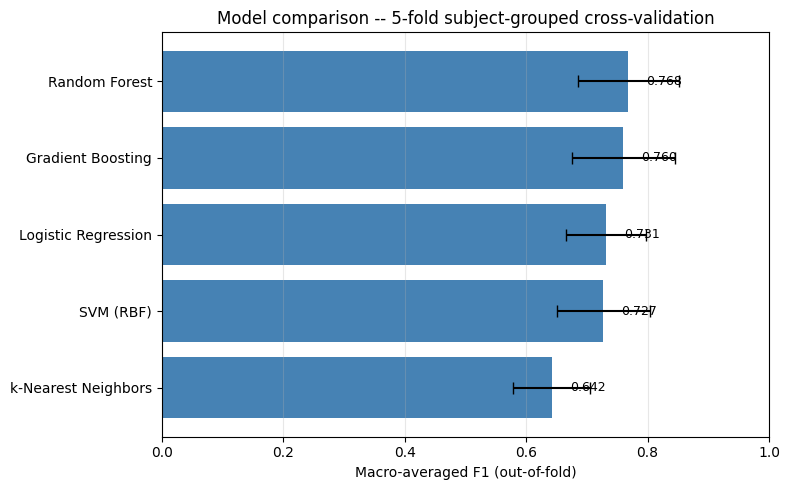

In [6]:
plot_df = summary_df.sort_values('oof_macro_f1')

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.barh(plot_df['model'], plot_df['oof_macro_f1'], xerr=plot_df['fold_macro_f1_std'],
                color='steelblue', capsize=4)
ax.set_xlabel('Macro-averaged F1 (out-of-fold)')
ax.set_xlim(0, 1)
ax.set_title('Model comparison -- 5-fold subject-grouped cross-validation')
ax.grid(axis='x', alpha=0.3)

for bar, value in zip(bars, plot_df['oof_macro_f1']):
    ax.text(min(value + 0.03, 0.97), bar.get_y() + bar.get_height() / 2, f'{value:.3f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

## Per-class detail -- best model

In [7]:
best_model_name = summary_df.iloc[0]['model']
print(f"Best model: {best_model_name}\n")
print(classification_report(y, results[best_model_name]['oof_predictions'], labels=CLASS_ORDER, digits=3))

Best model: Random Forest

                 precision    recall  f1-score   support

          Relax      0.844     0.824     0.834       709
 PhysicalStress      0.940     0.961     0.951       180
CognitiveStress      0.728     0.746     0.737       201
EmotionalStress      0.541     0.561     0.551       223

       accuracy                          0.786      1313
      macro avg      0.763     0.773     0.768      1313
   weighted avg      0.788     0.786     0.787      1313



## Confusion matrices -- all models

Row-normalized (each row sums to 1): shows, for windows truly belonging to a given phase, what fraction the model predicted for each phase.

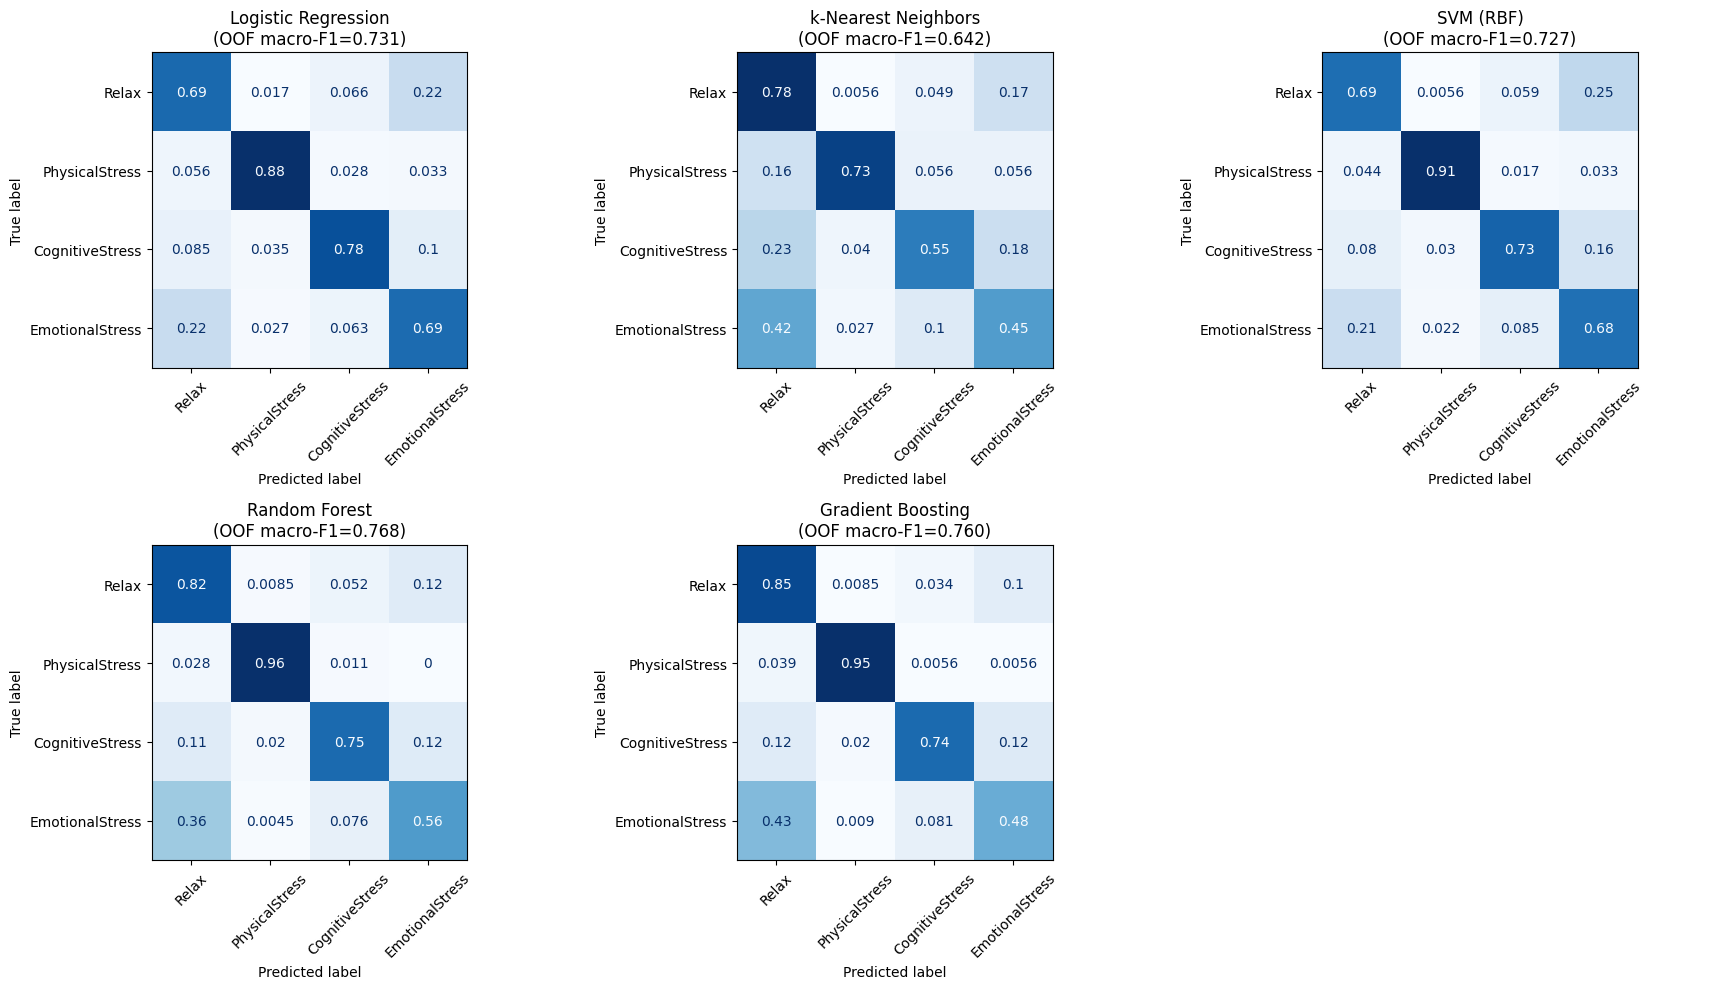

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.ravel()

for ax, (model_name, r) in zip(axes, results.items()):
    ConfusionMatrixDisplay.from_predictions(
        y, r['oof_predictions'], labels=CLASS_ORDER, normalize='true', cmap='Blues',
        ax=ax, colorbar=False, xticks_rotation=45,
    )
    ax.set_title(f"{model_name}\n(OOF macro-F1={r['oof_macro_f1']:.3f})")

for ax in axes[len(results):]:
    ax.axis('off')

plt.tight_layout()
plt.show()

## Feature importance

Random Forest, refit on the full dataset -- this fit is for interpretability only, not a performance claim (those come from the cross-validation above). Answers the question flagged early in `thesis_notes.md`'s Classification Decisions: are temperature and SpO2 actually low-importance, as the time-domain analysis in notebook 01/02 expected?

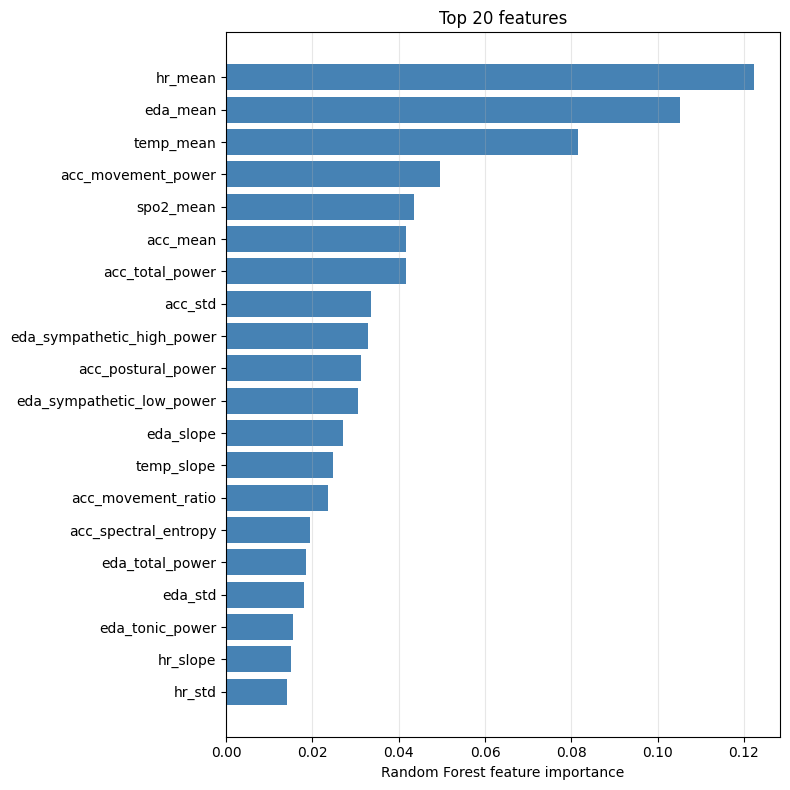

In [9]:
importance_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', RandomForestClassifier(n_estimators=300, class_weight='balanced', random_state=RANDOM_STATE)),
])
importance_pipeline.fit(X, y)

importance_df = pd.DataFrame({
    'feature': FEATURE_COLUMNS,
    'importance': importance_pipeline.named_steps['clf'].feature_importances_,
}).sort_values('importance', ascending=False).reset_index(drop=True)
importance_df['rank'] = importance_df.index + 1

top_n = 20
plot_df = importance_df.head(top_n).sort_values('importance')

fig, ax = plt.subplots(figsize=(8, 8))
ax.barh(plot_df['feature'], plot_df['importance'], color='steelblue')
ax.set_xlabel('Random Forest feature importance')
ax.set_title(f'Top {top_n} features')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

In [10]:
temp_spo2 = importance_df[importance_df['feature'].str.startswith(('temp_', 'spo2_'))]
print(f"temp_/spo2_ features occupy ranks {temp_spo2['rank'].min()}-{temp_spo2['rank'].max()} of {len(importance_df)}, "
      f"summing to {temp_spo2['importance'].sum() * 100:.1f}% of total importance "
      f"({len(temp_spo2)} features out of {len(importance_df)} total).")

temp_/spo2_ features occupy ranks 3-43 of 45, summing to 24.0% of total importance (14 features out of 45 total).


## Confound check -- is `temp_mean`'s importance real?

`temp_mean` ranked #3 in the feature-importance plot above, which is surprising: the signal notes in notebooks 01/02 expected Temp and SpO2 to rank low, on the grounds that skin temperature responds too slowly to be a stress marker and mostly just drifts upward for the whole session. Worth checking directly rather than taking the ranking at face value -- especially since Random Forest's built-in `feature_importances_` (impurity-based) is known to be biased toward continuous features, which is exactly what `temp_mean` is. `sklearn.inspection.permutation_importance` (shuffle a feature, measure how much the score degrades) is a more trustworthy alternative.

In [11]:
permutation_result = permutation_importance(
    importance_pipeline, X, y, n_repeats=15, random_state=RANDOM_STATE, scoring='f1_macro', n_jobs=-1
)
permutation_df = pd.DataFrame({
    'feature': FEATURE_COLUMNS,
    'permutation_importance': permutation_result.importances_mean,
}).sort_values('permutation_importance', ascending=False).reset_index(drop=True)
permutation_df['rank'] = permutation_df.index + 1

top_4_share = permutation_df.head(4)['permutation_importance'].sum() / permutation_df['permutation_importance'].sum()
print(f"Top 4 features carry {top_4_share * 100:.0f}% of total permutation importance:\n")
print(permutation_df[['rank', 'feature', 'permutation_importance']].head(10).to_string(index=False))

Top 4 features carry 66% of total permutation importance:

 rank             feature  permutation_importance
    1            eda_mean                0.034987
    2             hr_mean                0.031048
    3           temp_mean                0.028752
    4           spo2_mean                0.005801
    5           eda_slope                0.004663
    6          temp_slope                0.003085
    7 hr_spectral_entropy                0.002480
    8        acc_skewness                0.002201
    9           acc_slope                0.002198
   10              hr_std                0.002168


In [12]:
temp_window_corr = features_df['temp_mean'].corr(features_df['window_index'])
print(f"temp_mean vs window_index correlation: {temp_window_corr:.3f}")

temp_mean vs window_index correlation: 0.755


A correlation this strong (0.75) isn't a coincidence: every subject goes through the four phases in the same fixed order (Relax -> PhysicalStress -> Relax -> CognitiveStress -> Relax -> EmotionalStress -> Relax), and Temp drifts monotonically upward across the whole session regardless of which phase is active (see notebook 01/02 signal notes). `window_index` is literally "how far into the subject's window sequence is this row" -- so `temp_mean` is acting as a proxy for elapsed session time, not a genuine response to a specific stress type. A model trained on it could partly be learning "how far into this fixed protocol are we" rather than "what phase is this" -- a pattern that wouldn't hold up on a subject who did the phases in a different order or for a different session length.

Re-running the model comparison with all `temp_*`/`spo2_*` features excluded checks how much of the reported score depends on this.

In [13]:
no_confound_columns = [c for c in FEATURE_COLUMNS if not (c.startswith('temp_') or c.startswith('spo2_'))]
X_no_confound = features_df[no_confound_columns]

cv_no_confound = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

results_no_confound = {}
for model_name, pipeline in MODELS.items():
    oof_predictions = pd.Series(index=X_no_confound.index, dtype=object)
    fold_macro_f1 = []

    for train_idx, test_idx in cv_no_confound.split(X_no_confound, y, groups):
        pipeline.fit(X_no_confound.iloc[train_idx], y.iloc[train_idx])
        fold_predictions = pipeline.predict(X_no_confound.iloc[test_idx])
        oof_predictions.iloc[test_idx] = fold_predictions
        fold_macro_f1.append(f1_score(y.iloc[test_idx], fold_predictions, labels=CLASS_ORDER, average='macro'))

    results_no_confound[model_name] = {
        'oof_predictions': oof_predictions,
        'oof_macro_f1': f1_score(y, oof_predictions, labels=CLASS_ORDER, average='macro'),
        'oof_accuracy': accuracy_score(y, oof_predictions),
    }

print(f"{'Model':22s} {'macro-F1 (45 feat)':>20s} {'macro-F1 (31 feat)':>20s} {'Delta':>8s}")
print('-' * 74)
for model_name in MODELS:
    baseline = results[model_name]['oof_macro_f1']
    no_confound = results_no_confound[model_name]['oof_macro_f1']
    print(f"{model_name:22s} {baseline:>20.3f} {no_confound:>20.3f} {no_confound - baseline:>8.3f}")

Model                    macro-F1 (45 feat)   macro-F1 (31 feat)    Delta
--------------------------------------------------------------------------
Logistic Regression                   0.731                0.692   -0.039
k-Nearest Neighbors                   0.642                0.640   -0.002
SVM (RBF)                             0.727                0.689   -0.038
Random Forest                         0.768                0.745   -0.023
Gradient Boosting                     0.760                0.732   -0.028


### Per-class detail: does the confound-free model hold up class-by-class?

In [14]:
print(f"Best model: {best_model_name}\n")
print("-- All 45 features --")
print(classification_report(y, results[best_model_name]['oof_predictions'], labels=CLASS_ORDER, digits=3))
print("-- temp_*/spo2_* excluded (31 features) --")
print(classification_report(y, results_no_confound[best_model_name]['oof_predictions'], labels=CLASS_ORDER, digits=3))

Best model: Random Forest

-- All 45 features --
                 precision    recall  f1-score   support

          Relax      0.844     0.824     0.834       709
 PhysicalStress      0.940     0.961     0.951       180
CognitiveStress      0.728     0.746     0.737       201
EmotionalStress      0.541     0.561     0.551       223

       accuracy                          0.786      1313
      macro avg      0.763     0.773     0.768      1313
   weighted avg      0.788     0.786     0.787      1313

-- temp_*/spo2_* excluded (31 features) --
                 precision    recall  f1-score   support

          Relax      0.844     0.786     0.814       709
 PhysicalStress      0.902     0.922     0.912       180
CognitiveStress      0.716     0.751     0.733       201
EmotionalStress      0.484     0.561     0.520       223

       accuracy                          0.761      1313
      macro avg      0.737     0.755     0.745      1313
   weighted avg      0.771     0.761     0.765  

The first-pass hypothesis from notebooks 01/02 -- that Temp and SpO2 wouldn't be useful discriminators -- turns out to be **empirically wrong**: dropping them costs real score for every model except k-NN (which barely used them either way). Random Forest goes from 0.768 to 0.745; Logistic Regression and SVM lose even more (roughly -0.04 each), suggesting these two signals were adding real predictive value, not just noise.

The per-class breakdown for Random Forest shows where that value concentrates: PhysicalStress and EmotionalStress lose the most, while Relax and CognitiveStress barely move. PhysicalStress losing the most is worth a second look on its own terms -- transient SpO2 dips and skin-temperature changes during real physical exertion are physiologically plausible, which isn't actually in conflict with Temp/SpO2 being flat during *resting* mental-stress phases (the case the original signal notes were describing). Distinguishing "genuine exertion-related SpO2 signal" from "temp's session-position confound riding along in the same drop" would need testing each signal in isolation -- not done here, left as an open follow-up.

**Takeaway:** report **macro-F1 = 0.745** (Random Forest, `temp_*`/`spo2_*` excluded) as the trustworthy estimate of real-world performance -- it doesn't depend on a shortcut that's an artifact of this protocol's fixed phase ordering. The **0.768** headline number reported earlier is real but partly inflated by that shortcut, and shouldn't be quoted without this caveat.

## Summary

In [15]:
print(f"Best model: {best_model_name}")
print(f"  OOF macro-F1 = {results[best_model_name]['oof_macro_f1']:.3f}  (all 45 features)")
print(f"  OOF macro-F1 = {results_no_confound[best_model_name]['oof_macro_f1']:.3f}  (temp_*/spo2_* excluded -- more trustworthy, see confound check above)")
print(f"  OOF accuracy = {results[best_model_name]['oof_accuracy']:.3f}")
print()
print("Top 5 most important features (Random Forest, permutation importance):")
print(permutation_df[['rank', 'feature', 'permutation_importance']].head(5).to_string(index=False))

Best model: Random Forest
  OOF macro-F1 = 0.768  (all 45 features)
  OOF macro-F1 = 0.745  (temp_*/spo2_* excluded -- more trustworthy, see confound check above)
  OOF accuracy = 0.786

Top 5 most important features (Random Forest, permutation importance):
 rank   feature  permutation_importance
    1  eda_mean                0.034987
    2   hr_mean                0.031048
    3 temp_mean                0.028752
    4 spo2_mean                0.005801
    5 eda_slope                0.004663


## Limitations

- No hyperparameter tuning was done -- this is a baseline comparison at default (or lightly reasoned) parameters, not each model's ceiling performance.
- Only 20 subjects: `StratifiedGroupKFold` folds hold out 4 subjects at a time, so per-fold scores can be noisy; the fold mean/std reported above is a better estimate of variability than any single fold.
- k-Nearest Neighbors has no `class_weight` equivalent, so it doesn't get the same class-imbalance correction the other four models do.
- The 0.768 headline macro-F1 is partly inflated by a session-position confound in `temp_mean` (correlates 0.75 with `window_index`, an artifact of every subject following the same fixed phase order -- see "Confound check" above); 0.745 (temp_*/spo2_* excluded) is the more defensible estimate of real-world performance.